# GlandSeg Classification Script

## To do next:
* Improve augmentations to simulate change in staining --> Re-train contrastive learning encoder.
* Implement saving mask of each gland --> Refine visualisations of gland clusters in situ.

In [1]:
##############
## INITIATE ##
##############

## Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import pickle
from PIL import Image
from torchvision import transforms
from sklearn.neighbors import KNeighborsClassifier

## Import modules
from f_wsi_reader import slide_path_to_tiles_at_coordinates
from f_wsi_reader import get_tile_map
from f_wsi_reader import get_tile_map_fast
from f_wsi_reader import read_slide
from f_wsi_reader import get_dimensions
from f_wsi_reader import apply_all_filters
from f_wsi_reader import apply_all_transforms
from f_wsi_reader import reassemble_tiles
from f_wsi_reader import select_patches_on_grid
from f_wsi_reader import get_tissue_mask
from f_extract_objects import extract_object_pixels
from f_extract_objects import polish
from f_extract_objects import inlay_objects
from f_extract_objects import get_bounding_box_square
# from f_model import UNet as Model
from f_model_transformer import UNetTransformer as Model

#
###

/Users/willembonnaffe/anaconda3/envs/pytorch/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
###############
## FUNCTIONS ##
###############

def load_encoder(encoder_path, device='cpu'):
    """
    Loads a pre-trained ResNet18 encoder.

    Args:
        encoder_path (str): Path to the saved encoder weights.
        device (str): Device to load the encoder onto ('cpu' or 'cuda').

    Returns:
        torch.nn.Module: The loaded ResNet18 encoder.
    """
    from torchvision.models import resnet18
    
    # Define the encoder class (ResNet18 without classification layer)
    class ResNet18Encoder(torch.nn.Module):
        def __init__(self):
            super(ResNet18Encoder, self).__init__()
            self.resnet18 = resnet18(pretrained=True)
            self.resnet18 = torch.nn.Sequential(*list(self.resnet18.children())[:-1])  # Remove the FC layer
            self.flatten = torch.nn.Flatten()

        def forward(self, x):
            x = self.resnet18(x)
            x = self.flatten(x)
            return x
    
    # Initialize and load the encoder
    encoder = ResNet18Encoder()
    encoder.load_state_dict(torch.load(encoder_path, map_location=device))
    encoder.to(device)
    encoder.eval()  # Set to evaluation mode
    return encoder

def load_knn_classifier(knn_model_path):
    """
    Loads the pre-trained k-NN classifier from a file.

    Args:
        knn_model_path (str): Path to the saved k-NN classifier file.

    Returns:
        KNeighborsClassifier: The loaded k-NN classifier.
    """
    with open(knn_model_path, 'rb') as f:
        knn_classifier = pickle.load(f)
    return knn_classifier

def encode_image(image_path, encoder):
    """
    Encodes an image into its high-dimensional embedding using the pre-trained encoder.
    
    Args:
        image_path (str): Path to the input image.
        encoder (torch.nn.Module): Pre-trained ResNet18 encoder.        
    
    Returns:
        torch.Tensor: The high-dimensional embedding of the image.
    """
    ## Load and preprocess the image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    ## Apply preprocessing: CLAHE, resize, normalization
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(image)
    l = clahe.apply(l)
    image = cv2.merge((l, a, b))
    image = cv2.cvtColor(image, cv2.COLOR_LAB2RGB)
    image = cv2.resize(image, (224, 224))

    ## Convert image to PIL format for transforms
    image = Image.fromarray(image)

    ## Define the same transformation pipeline used during training
    transform = transforms.Compose([    
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    ## Transformations
    image = transform(image)  # Apply the same transformation pipeline used during training

    ## Add a batch dimension (for a single image)
    image = image.unsqueeze(0)

    ## Ensure the encoder is in evaluation mode
    encoder.eval()

    ## Generate the embedding
    with torch.no_grad():  # Disable gradients for inference
        embedding = encoder(image)

    return embedding

def predict_cluster(image_embedding, knn_classifier):
    """
    Predicts the cluster for a given image embedding using the pre-trained k-NN classifier.
    
    Args:
        image_embedding (torch.Tensor): The embedding of the image.
        knn_classifier (sklearn.neighbors.KNeighborsClassifier): Pre-trained k-NN classifier.
    
    Returns:
        int: The predicted cluster label.
    """
    ## Convert the embedding to a NumPy array (k-NN expects NumPy input)
    image_embedding_np = image_embedding.cpu().numpy()

    ## Predict the cluster using k-NN
    predicted_cluster = knn_classifier.predict(image_embedding_np)

    return predicted_cluster[0]  # Return the predicted cluster label

#
###

In [35]:
#########################
## INITIATE CLASSIFIER ##
#########################

## Paths to the pre-trained encoder and k-NN classifier
encoder_path = '/Users/willembonnaffe/Documents/GitHub/GlandSeg/scripts/b2_0_0/p_classify_glands/scripts/V0_0_0/model_TCGA_V0_3.pth'
knn_model_path = '/Users/willembonnaffe/Documents/GitHub/GlandSeg/scripts/b2_0_0/p_classify_glands/scripts/V0_0_0/knn_classifier.pkl'

## Device setup
device = 'cpu'  # or 'cuda' if GPU is available

## Load the pre-trained ResNet18 encoder
encoder = load_encoder(encoder_path, device=device)

## Load the pre-trained k-NN classifier
knn_classifier = load_knn_classifier(knn_model_path)

#
###

/Users/willembonnaffe/anaconda3/envs/pytorch/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/willembonnaffe/anaconda3/envs/pytorch/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [36]:
######################
## APPLY CLASSIFIER ##
######################

## Parameters
PTIF = '/Users/willembonnaffe/Documents/Academia/Projects/GlandSeg/V2_0_0/TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs_extracted_glands/'
# PTIF = '/Users/willembonnaffe/Documents/Academia/Projects/GlandSeg/V2_0_0/TB10.1062_V1_11.svs_extracted_glands/'
image_paths = os.listdir(PTIF)
image_paths = [PTIF + image_path for image_path in image_paths] # Add root

cluster_labels = []
coords_list = []
for image_path in image_paths:

    ## Check path
    print(os.path.basename(image_path))

    image_name = os.path.basename(image_path)    
    name = image_name.replace('.png','').replace('.svs','').split('__')[0]
    coords_list += [image_name.replace('.png','').replace('.svs','').split('__')[1].split('_')]
   
    ## Encode the new image to obtain its embedding
    image_embedding = encode_image(image_path, encoder)
    
    ## Predict the cluster for the new image using the k-NN classifier
    predicted_cluster = predict_cluster(image_embedding, knn_classifier)
    print(f'The predicted cluster for the image is: {predicted_cluster}')

    ## Collect
    cluster_labels += [predicted_cluster]    

#
###

TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs__49064_50360_28272_29568.png
The predicted cluster for the image is: 8
TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs__42144_42512_30064_30432.png
The predicted cluster for the image is: 9
TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs__28720_28768_12736_12784.png
The predicted cluster for the image is: 2
TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs__23112_23368_33376_33632.png
The predicted cluster for the image is: 7
TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs__42800_42896_21240_21336.png
The predicted cluster for the image is: 2
TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs__24704_24752_25632_25680.png
The predicted cluster for the image is: 2
TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs__52488_52792_24192_24496.png
The predicted cluster for the image is: 10
TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4

IndexError: list index out of range

In [37]:
###########
## PATHS ##
###########

## Paths
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/train/EU_37106_15_2K_HandE+-+2017-11-28+11.43.55_TissueTrain_(1.00,63062,11375,5880,10230)/reference/EU_37106_15_2K_HandE+-+2017-11-28+11.43.55_TissueTrain_(1.00,63062,11375,5880,10230).png']
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0a93d9a674e358ba32e4e2ec320aefc5.tiff'] # PANDA example 1
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0bfe4af623f6be66a82289e411320773.tiff'] # PANDA example 2
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/TCGA/images/svs/TCGA-EJ-5509-01A_1.svs'] # TCGA
# wsi_paths = '/Volumes/SED/BDI/databases/RAW/datasets/ICGCC/images/svs/TB10.0575_V2_1.svs',
# wsi_paths = '/Volumes/SED/BDI/databases/RAW/datasets/ICGCC/images/svs/TB10.1062_V1_11.svs',
wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/TCGA_FFPE/downloads/ffpes/TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs']

#
###

In [38]:
##########################
## GET TILE COORDINATES ##
##########################

## Parameters
TILE_SIZE = 64 # Size of tiles for tissue extraction
FILTER_LOW = 10 # Low filter to remove black tiles
FILTER_HIGH = 240 # High filter to remove white tiles
FILTER_STD = 2 # Std filter to remove grey tiles
WSI_PATH = wsi_paths[0] # Path to WSI

## Open slide
slide = read_slide(WSI_PATH)
slide_size = get_dimensions(slide)

## Get tile_map
thumbnail, tile_map, canvas_size = get_tile_map(slide, TILE_SIZE)

## Get tissue mask
mask = get_tissue_mask(tile_map, FILTER_LOW, FILTER_STD, FILTER_HIGH)

## Get coordinates of tiles with tissue
tile_coordinates = (np.argwhere(mask[:,:,0] > 0) * TILE_SIZE).astype(int)
tile_coordinates = [[tile_coordinate[0], tile_coordinate[1]] for tile_coordinate in tile_coordinates] # (x: H, y: W)

## Compute slide-level tissue mask
tissue_mask = cv2.resize(mask, (canvas_size[1], canvas_size[0]), cv2.INTER_LINEAR)[:,:,None] # (H, W)

#
###

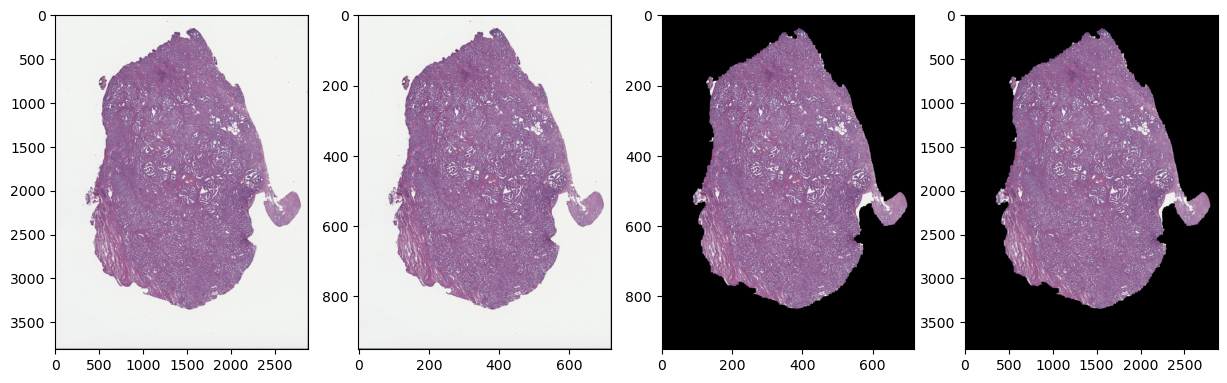

In [27]:
###################################
## GET TILE COORDINATES - CHECKS ##
###################################

## Compute pixel-tile tissue mask (For checks)
tile_map_masked = tile_map * mask
thumbnail_masked = thumbnail * cv2.resize(mask, (thumbnail.shape[1], thumbnail.shape[0]), cv2.INTER_LINEAR)[:,:,None] # (H, W)

## Visualise mask
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(thumbnail)
axes[1].imshow(tile_map)
axes[2].imshow(tile_map_masked)
axes[3].imshow(thumbnail_masked)
plt.show()
plt.close()

#
###

In [28]:
###############################
## EXTRACT PATCHES FOR MODEL ##
###############################

## Parameters
LEVEL = 0 # Downsampling level 
TILE_SIZE_MODEL = 1024 # Size of tile for model

## Remove patches too close to the edges
tile_coordinates_thinned = []
for tile_coordinates_ in tile_coordinates:
    coords_0_lo = tile_coordinates_[0] + int(TILE_SIZE/2) - int(TILE_SIZE_MODEL/2)
    coords_0_hi = tile_coordinates_[0] + int(TILE_SIZE/2) + int(TILE_SIZE_MODEL/2)
    coords_1_lo = tile_coordinates_[1] + int(TILE_SIZE/2) - int(TILE_SIZE_MODEL/2)
    coords_1_hi = tile_coordinates_[1] + int(TILE_SIZE/2) + int(TILE_SIZE_MODEL/2)
    if (coords_0_lo > 0) & (coords_0_hi < canvas_size[0]) & (coords_1_lo > 0) & (coords_1_hi < canvas_size[1]):
        tile_coordinates_thinned += [[coords_0_lo, coords_1_lo]]

## Get patches closest to grid points
tile_coordinates_thinned = select_patches_on_grid(tile_coordinates_thinned, grid_spacing=512)

## Load patches from the dataset
patches = slide_path_to_tiles_at_coordinates(WSI_PATH, tile_coordinates_thinned, TILE_SIZE_MODEL, LEVEL) # [dataset[i] for i in range(min(num_patches_to_display, len(dataset)))]
print(f'Number of patches: {len(tile_coordinates_thinned)}')

#
###

Number of patches: 5131


In [29]:
####################
## REASSEMBLE WSI ##
####################

## Reassemble image
img = reassemble_tiles(patches, tile_coordinates_thinned, canvas_size[0], canvas_size[1])

## Mask
img = img * tissue_mask

#
###

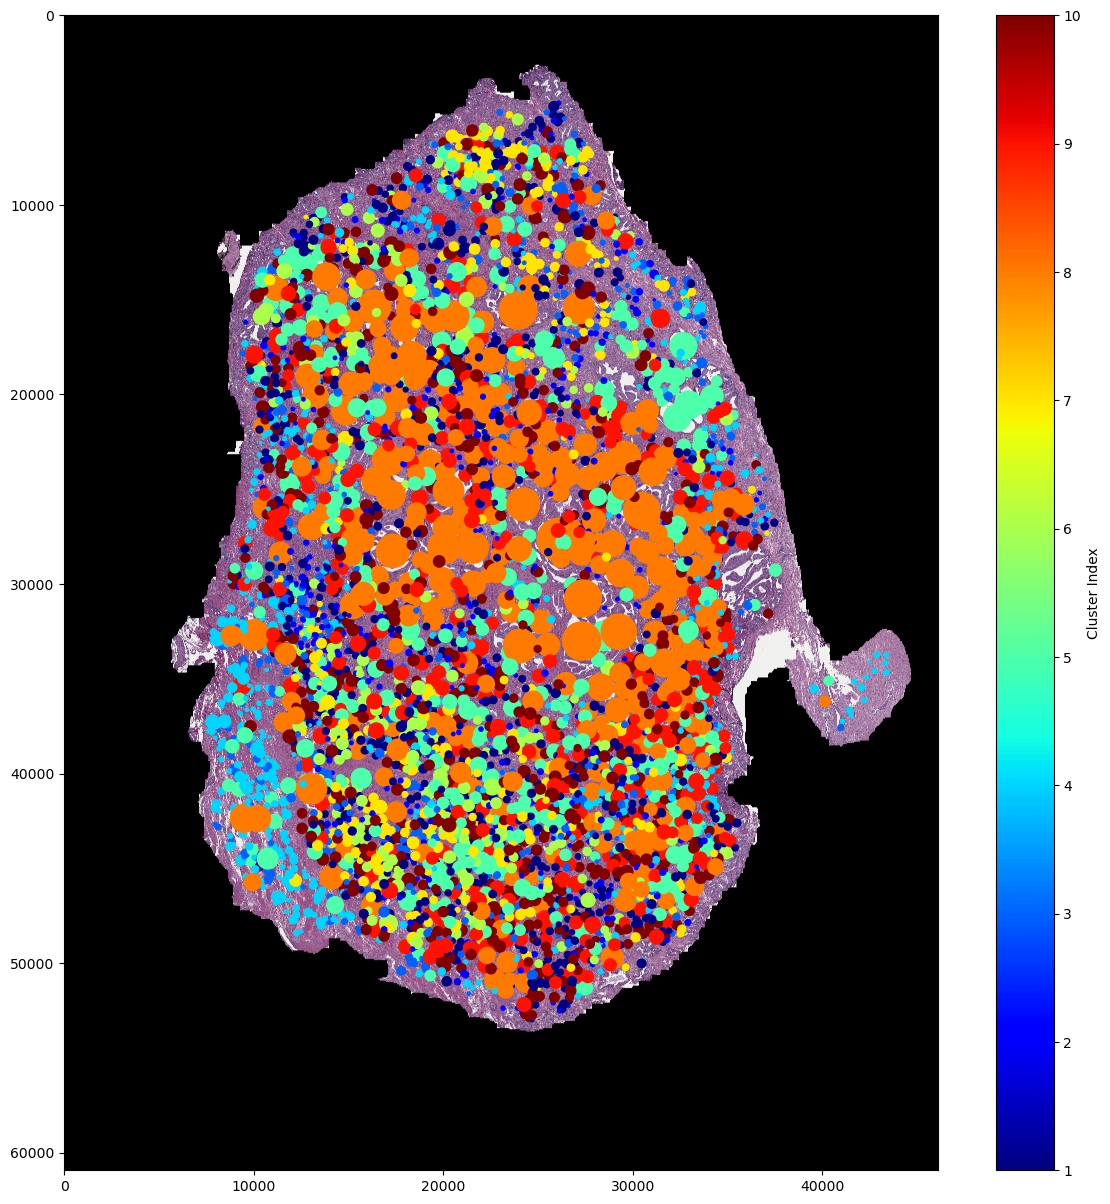

In [49]:
#############################
## REASSEMBLE WSI - CHECKS ##
#############################

## Format coordinates
coords = np.array(coords_list).astype(int)

## Visualise
fig, axes = plt.subplots(1, 1, figsize=(15, 15))
axes.imshow(img)
x = (coords[:,1] + coords[:,0])//2
y = (coords[:,3] + coords[:,2])//2
s = (np.abs(coords[:,3] - coords[:,2]) + np.abs(coords[:,1] - coords[:,0]))//10
scatter = axes.scatter(y, x, c=cluster_labels, cmap='jet', s=s)
fig.colorbar(scatter, ax=axes, ticks=range(1, 10 + 1), label='Cluster Index')
plt.show()
plt.close()

#
###

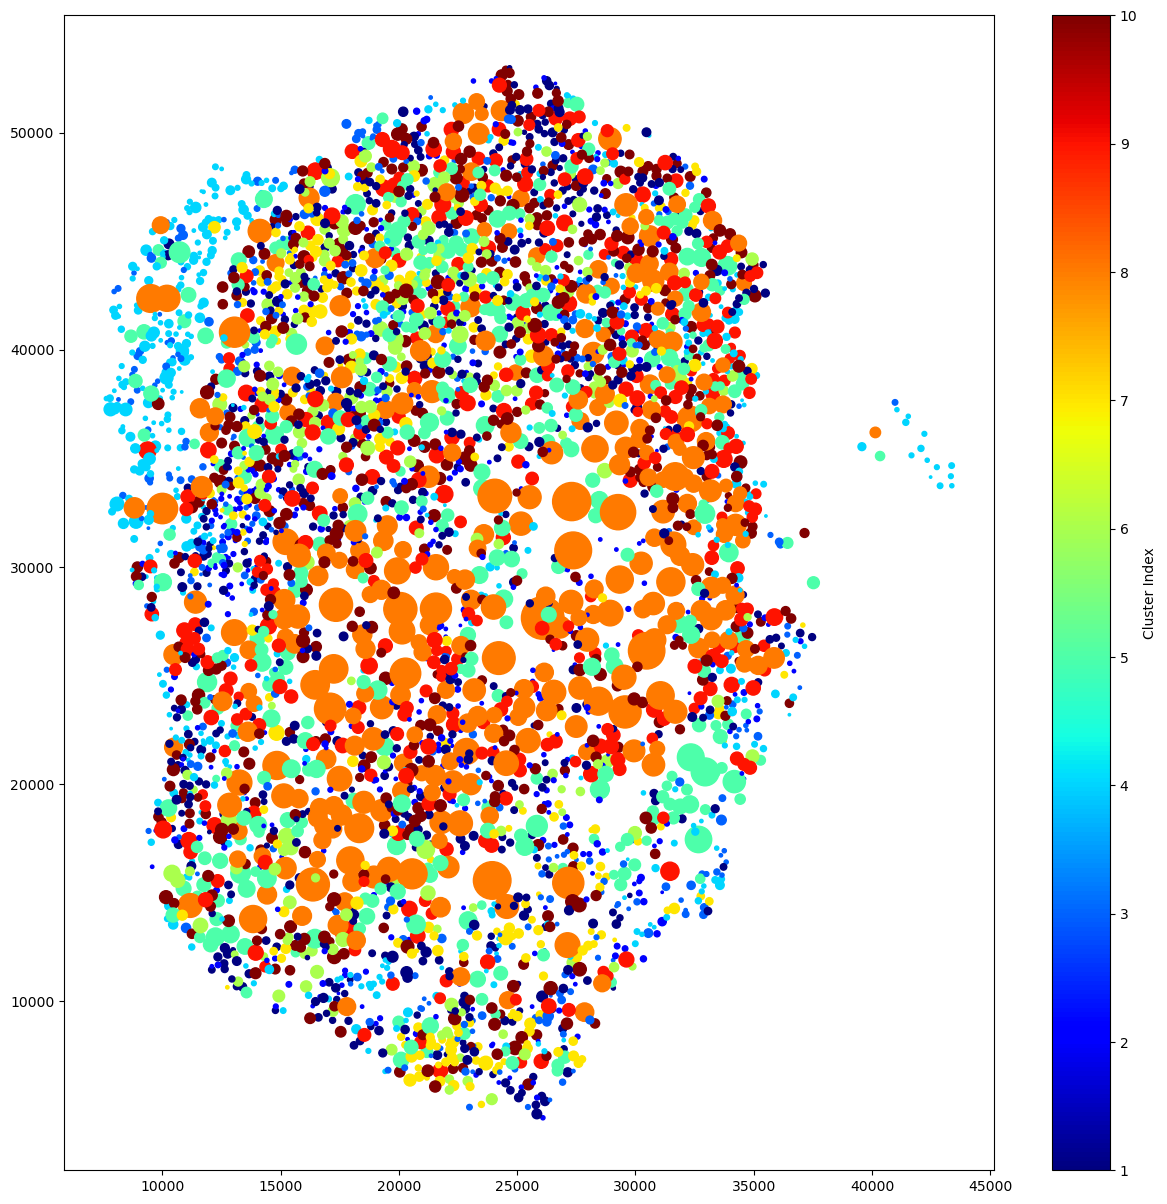

In [48]:
## Visualise
fig, axes = plt.subplots(1, 1, figsize=(15, 15))
axes.imshow(img)
x = (coords[:,1] + coords[:,0])//2
y = (coords[:,3] + coords[:,2])//2
s = (np.abs(coords[:,3] - coords[:,2]) + np.abs(coords[:,1] - coords[:,0]))//10
scatter = axes.scatter(y, x, c=cluster_labels, cmap='jet', s=s)
fig.colorbar(scatter, ax=axes, ticks=range(1, 10 + 1), label='Cluster Index')
plt.show()
plt.close()
